In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [9]:
avg_rn = []
rn = []
dlist = np.linspace(0, 0.5, 41)
N = 14
wd = 0.642570281124498
tlist = np.linspace(0, 100, 300)
H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
basisLen = len(basisList)

for d in dlist:
    temp = []
    diag_vals = np.random.uniform(-d, d, basisLen)
    diag_vals -= np.mean(diag_vals)
    diagLocation = list(range(basisLen))
    H_anharm = csr_matrix((diag_vals, (diagLocation, diagLocation)), shape=(basisLen, basisLen))
    H_anharm = qt.Qobj(H_anharm)

    Hscar = H0 + H_anharm
    deigvals, deigstates = Hscar.eigenstates()

    for i in range(len(deigvals) - 2):
        deltaE0 = deigvals[i+1] - deigvals[i]
        deltaE1 = deigvals[i+2] - deigvals[i+1]
        temp.append(np.min([deltaE0, deltaE1]) / np.max([deltaE0, deltaE1]))
    rn.append(temp)

for i in range(len(rn)):
    avg_rn.append(np.mean(rn[i]))

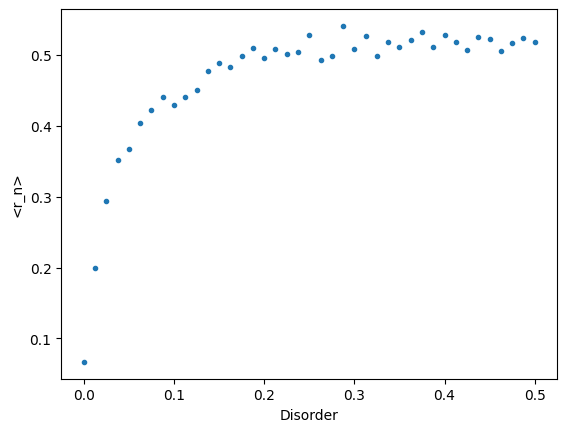

In [ ]:
plt.xlabel("Disorder")
plt.ylabel("<r_n>")
plt.plot(dlist, avg_rn, ".")
plt.show()